# Chapter 12.6: Multi-Objective Ecosystem Optimization

## Learning Objectives

By the end of this notebook, you will be able to:

1. Model multi-stakeholder recommendation ecosystems (users, creators, platform)
2. Implement multi-objective optimization with Pareto-optimal solutions
3. Simulate creator economy dynamics and recommendation impact on creators
4. Design supply-demand balancing for two-sided marketplace recommendations
5. Optimize for long-term ecosystem health vs short-term engagement
6. Apply scalarization and evolutionary methods for multi-objective optimization
7. Detect and prevent ecosystem collapse scenarios

## Prerequisites

- Understanding of multi-objective optimization
- Familiarity with marketplace dynamics
- Knowledge of reinforcement learning basics (Part 10)
- PyTorch proficiency

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part12/chapter_12.6_ecosystem.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part12/chapter_12.6_ecosystem.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import defaultdict
import copy

np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cpu')

print("All imports successful!")

All imports successful!


## 1. The Multi-Stakeholder Ecosystem

A recommendation platform serves multiple stakeholders:

- **Users**: Want relevant, diverse, high-quality content
- **Creators**: Want exposure, growth, fair distribution of attention
- **Advertisers**: Want targeted reach and conversion
- **Platform**: Wants long-term engagement, revenue, and ecosystem health

The multi-objective optimization problem:

$$\max_{\pi} \left(f_{\text{user}}(\pi), f_{\text{creator}}(\pi), f_{\text{revenue}}(\pi), f_{\text{health}}(\pi)\right)$$

These objectives often conflict: maximizing short-term user engagement may
concentrate attention on a few creators, harming ecosystem diversity.

> **💡 Concept:** There is no single optimal solution when objectives conflict. Instead, we
> seek the **Pareto frontier**: the set of solutions where no objective can be improved
> without worsening another.

In [2]:
class RecommendationEcosystem:
    """Simulate a multi-stakeholder recommendation ecosystem."""
    
    def __init__(self, n_users=200, n_creators=50, n_items_per_creator=10):
        self.n_users = n_users
        self.n_creators = n_creators
        self.n_items = n_creators * n_items_per_creator
        
        # Item-to-creator mapping
        self.item_creator = np.repeat(np.arange(n_creators), n_items_per_creator)
        
        # User preferences (latent factors)
        self.user_factors = np.random.randn(n_users, 16) * 0.3
        # Item quality (latent factors)
        self.item_factors = np.random.randn(self.n_items, 16) * 0.3
        # Creator quality (some creators produce higher quality content)
        self.creator_quality = np.random.beta(2, 5, n_creators)  # Right-skewed
        for i in range(self.n_items):
            self.item_factors[i] *= (0.5 + self.creator_quality[self.item_creator[i]])
        
        # Creator state
        self.creator_exposure = np.zeros(n_creators)  # Total exposure received
        self.creator_active = np.ones(n_creators, dtype=bool)  # Still active?
        self.creator_satisfaction = np.ones(n_creators) * 0.5
        
        # Revenue model: items have ad potential
        self.item_ad_value = np.random.exponential(0.1, self.n_items)
        
        self.step_count = 0
    
    def recommend_and_observe(self, rec_items_per_user):
        """Process one round of recommendations.
        rec_items_per_user: (n_users, k) array of recommended item indices
        Returns dict of ecosystem metrics.
        """
        self.step_count += 1
        
        # User satisfaction: relevance of recommendations
        user_satisfaction = []
        for u in range(self.n_users):
            items = rec_items_per_user[u]
            scores = [np.dot(self.user_factors[u], self.item_factors[i]) for i in items]
            user_satisfaction.append(np.mean(scores))
        
        # Creator exposure tracking
        exposure_this_round = np.zeros(self.n_creators)
        for u in range(self.n_users):
            for item in rec_items_per_user[u]:
                creator = self.item_creator[item]
                exposure_this_round[creator] += 1
        
        self.creator_exposure += exposure_this_round
        
        # Creator satisfaction: based on exposure fairness
        mean_exposure = exposure_this_round.mean()
        for c in range(self.n_creators):
            if self.creator_active[c]:
                expected = mean_exposure * self.creator_quality[c] * 2
                ratio = exposure_this_round[c] / max(1, expected)
                self.creator_satisfaction[c] = 0.9 * self.creator_satisfaction[c] + 0.1 * min(ratio, 1.0)
                # Creators leave if satisfaction drops too low
                if self.creator_satisfaction[c] < 0.1 and self.step_count > 5:
                    self.creator_active[c] = False
        
        # Revenue
        total_revenue = 0
        for u in range(self.n_users):
            for item in rec_items_per_user[u]:
                click_prob = max(0, np.dot(self.user_factors[u], self.item_factors[item]) + 0.5)
                click_prob = min(click_prob, 1.0)
                total_revenue += click_prob * self.item_ad_value[item]
        
        # Ecosystem diversity (Gini coefficient of creator exposure)
        sorted_exp = np.sort(exposure_this_round)
        n = len(sorted_exp)
        index = np.arange(1, n + 1)
        gini = (np.sum((2 * index - n - 1) * sorted_exp)) / (n * np.sum(sorted_exp) + 1e-8)
        
        return {
            'user_satisfaction': np.mean(user_satisfaction),
            'creator_satisfaction': np.mean(self.creator_satisfaction[self.creator_active]),
            'active_creators': np.sum(self.creator_active),
            'revenue': total_revenue,
            'exposure_gini': gini,  # 0=equal, 1=concentrated
            'creator_exposure_std': np.std(exposure_this_round)
        }

eco = RecommendationEcosystem()
# Random recommendations
recs = np.random.randint(0, eco.n_items, (eco.n_users, 10))
metrics = eco.recommend_and_observe(recs)
print("Ecosystem metrics (random policy):")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

Ecosystem metrics (random policy):
  user_satisfaction: -0.0105
  creator_satisfaction: 0.5476
  active_creators: 50.0000
  revenue: 99.8424
  exposure_gini: 0.0845
  creator_exposure_std: 5.9397


## 2. Recommendation Policies

We compare different recommendation strategies and their ecosystem impact:

1. **Greedy engagement**: Maximize user clicks (short-term)
2. **Fair exposure**: Distribute attention proportionally to creator quality
3. **Revenue-maximizing**: Prioritize items with high ad value
4. **Balanced**: Multi-objective optimization

> **⚠️ Common Pitfall:** Pure engagement optimization creates a "rich get richer" effect
> where top creators get all the exposure, causing smaller creators to leave the platform.

In [3]:
def greedy_engagement_policy(eco, k=10):
    """Maximize user-item relevance."""
    recs = np.zeros((eco.n_users, k), dtype=int)
    for u in range(eco.n_users):
        scores = eco.item_factors @ eco.user_factors[u]
        top_items = np.argsort(scores)[-k:][::-1]
        recs[u] = top_items
    return recs

def fair_exposure_policy(eco, k=10):
    """Balance exposure across active creators."""
    recs = np.zeros((eco.n_users, k), dtype=int)
    active_items = [i for i in range(eco.n_items) if eco.creator_active[eco.item_creator[i]]]
    
    for u in range(eco.n_users):
        # Score items but boost under-exposed creators
        scores = eco.item_factors @ eco.user_factors[u]
        exposure_penalty = np.zeros(eco.n_items)
        for i in range(eco.n_items):
            c = eco.item_creator[i]
            exposure_penalty[i] = eco.creator_exposure[c] * 0.01
        adjusted_scores = scores - exposure_penalty
        # Only consider active creators' items
        mask = np.full(eco.n_items, -np.inf)
        mask[active_items] = 0
        adjusted_scores += mask
        top_items = np.argsort(adjusted_scores)[-k:][::-1]
        recs[u] = top_items
    return recs

def revenue_policy(eco, k=10):
    """Maximize ad revenue."""
    recs = np.zeros((eco.n_users, k), dtype=int)
    for u in range(eco.n_users):
        scores = eco.item_factors @ eco.user_factors[u]
        click_probs = np.clip(scores + 0.5, 0, 1)
        expected_revenue = click_probs * eco.item_ad_value
        top_items = np.argsort(expected_revenue)[-k:][::-1]
        recs[u] = top_items
    return recs

def balanced_policy(eco, k=10, alpha=0.5, beta=0.3, gamma=0.2):
    """Multi-objective balanced policy."""
    recs = np.zeros((eco.n_users, k), dtype=int)
    for u in range(eco.n_users):
        relevance = eco.item_factors @ eco.user_factors[u]
        relevance = (relevance - relevance.min()) / (relevance.max() - relevance.min() + 1e-8)
        
        exposure_penalty = np.zeros(eco.n_items)
        for i in range(eco.n_items):
            c = eco.item_creator[i]
            exposure_penalty[i] = eco.creator_exposure[c] * 0.001
        fairness = 1.0 / (1.0 + exposure_penalty)
        fairness = (fairness - fairness.min()) / (fairness.max() - fairness.min() + 1e-8)
        
        rev = np.clip(eco.item_factors @ eco.user_factors[u] + 0.5, 0, 1) * eco.item_ad_value
        rev = (rev - rev.min()) / (rev.max() - rev.min() + 1e-8)
        
        combined = alpha * relevance + beta * fairness + gamma * rev
        top_items = np.argsort(combined)[-k:][::-1]
        recs[u] = top_items
    return recs

print("Policies defined.")

Policies defined.


In [4]:
# Simulate ecosystem evolution under different policies
def simulate_ecosystem(policy_fn, n_rounds=30, **policy_kwargs):
    eco = RecommendationEcosystem()
    history = []
    for r in range(n_rounds):
        recs = policy_fn(eco, **policy_kwargs)
        metrics = eco.recommend_and_observe(recs)
        metrics['round'] = r
        history.append(metrics)
    return history

policies = {
    'Greedy Engagement': (greedy_engagement_policy, {}),
    'Fair Exposure': (fair_exposure_policy, {}),
    'Revenue Max': (revenue_policy, {}),
    'Balanced': (balanced_policy, {})
}

all_histories = {}
for name, (fn, kwargs) in policies.items():
    hist = simulate_ecosystem(fn, **kwargs)
    all_histories[name] = hist
    final = hist[-1]
    print(f"{name:20s}: UserSat={final['user_satisfaction']:.3f}, "
          f"CreatorSat={final['creator_satisfaction']:.3f}, "
          f"Active={final['active_creators']}, Revenue={final['revenue']:.1f}")

Greedy Engagement   : UserSat=0.743, CreatorSat=0.872, Active=50, Revenue=226.2


Fair Exposure       : UserSat=0.596, CreatorSat=0.509, Active=50, Revenue=191.1


Revenue Max         : UserSat=0.237, CreatorSat=0.857, Active=31, Revenue=605.4


Balanced            : UserSat=0.576, CreatorSat=0.809, Active=50, Revenue=331.4


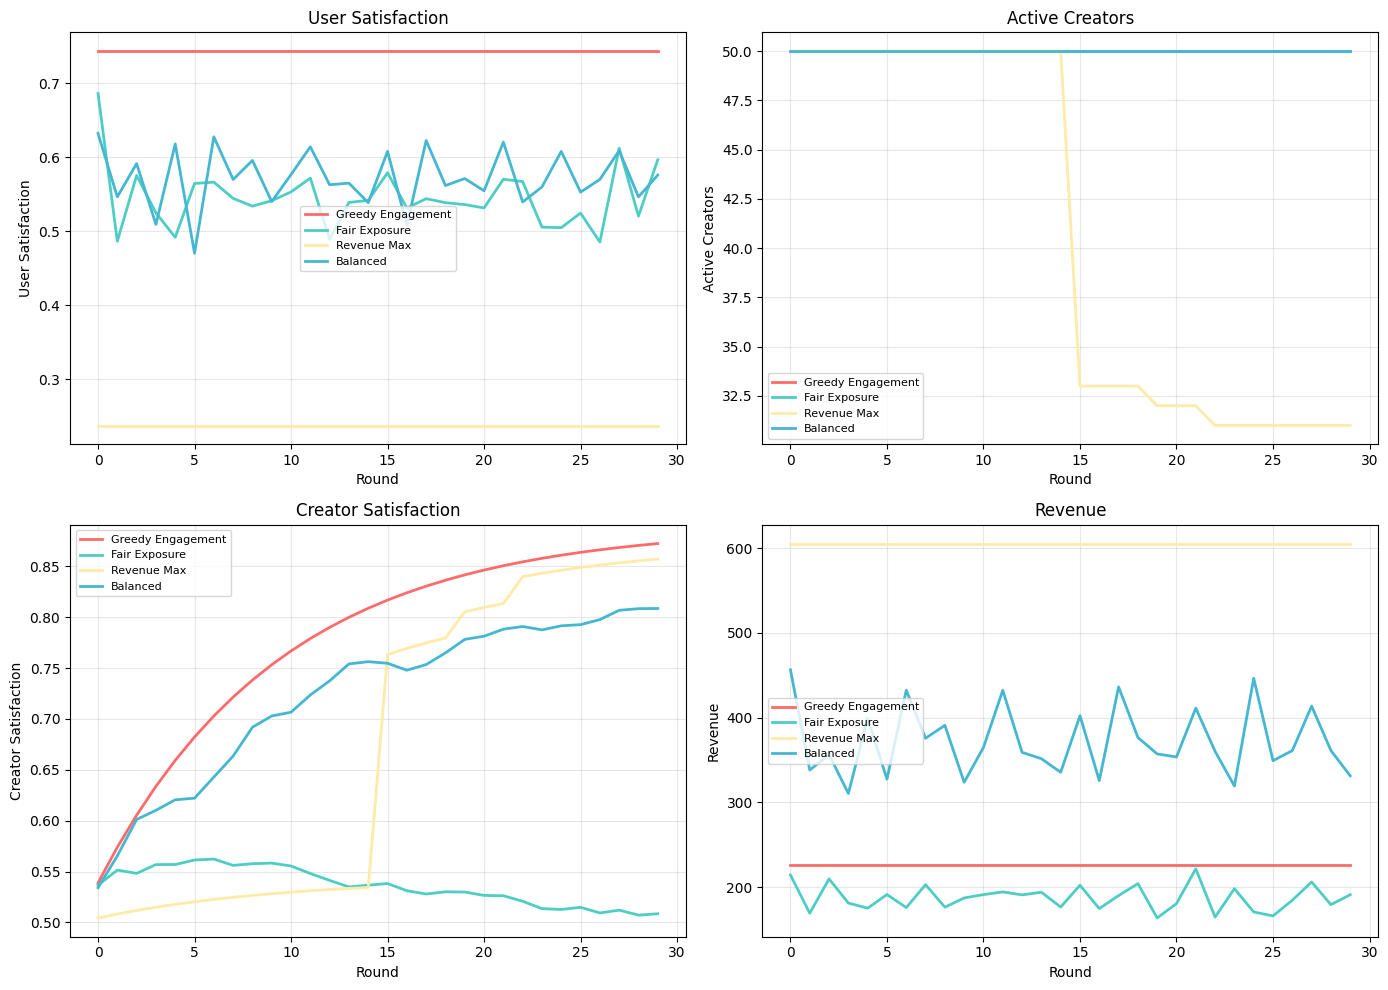

In [5]:
# Visualize ecosystem evolution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ('user_satisfaction', 'User Satisfaction'),
    ('active_creators', 'Active Creators'),
    ('creator_satisfaction', 'Creator Satisfaction'),
    ('revenue', 'Revenue')
]

colors = {'Greedy Engagement': '#FF6B6B', 'Fair Exposure': '#4ECDC4',
          'Revenue Max': '#FFEAA7', 'Balanced': '#45B7D1'}

for ax, (metric, title) in zip(axes.flatten(), metrics_to_plot):
    for name, hist in all_histories.items():
        values = [h[metric] for h in hist]
        ax.plot(values, label=name, linewidth=2, color=colors[name])
    ax.set_xlabel('Round')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Pareto Frontier Analysis

We explore the trade-off space by varying the weights in the balanced policy.

A solution $x$ **Pareto dominates** $y$ if $x$ is at least as good as $y$ in all objectives
and strictly better in at least one.

$$x \succ y \iff \forall i: f_i(x) \geq f_i(y) \land \exists j: f_j(x) > f_j(y)$$

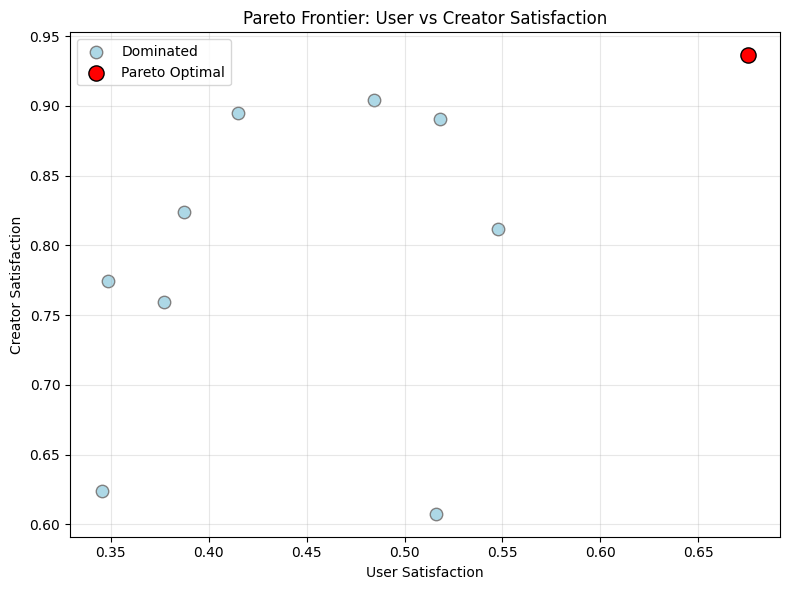

Found 1 Pareto-optimal configurations out of 10


In [6]:
# Sweep weight combinations to find Pareto frontier
pareto_points = []
weight_configs = []

for alpha in np.arange(0.1, 1.0, 0.2):
    for beta in np.arange(0.1, 1.0 - alpha, 0.2):
        gamma = 1.0 - alpha - beta
        if gamma < 0:
            continue
        hist = simulate_ecosystem(balanced_policy, n_rounds=20,
                                   alpha=alpha, beta=beta, gamma=gamma)
        final = hist[-1]
        pareto_points.append([
            final['user_satisfaction'],
            final['creator_satisfaction'],
            final['revenue']
        ])
        weight_configs.append((alpha, beta, gamma))

pareto_points = np.array(pareto_points)

# Find Pareto-optimal points (2D projection: user sat vs creator sat)
def is_pareto_optimal(points):
    """Find Pareto-optimal points."""
    n = len(points)
    is_optimal = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j:
                if np.all(points[j] >= points[i]) and np.any(points[j] > points[i]):
                    is_optimal[i] = False
                    break
    return is_optimal

optimal_mask = is_pareto_optimal(pareto_points[:, :2])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pareto_points[~optimal_mask, 0], pareto_points[~optimal_mask, 1],
           c='lightblue', s=80, label='Dominated', edgecolors='gray')
ax.scatter(pareto_points[optimal_mask, 0], pareto_points[optimal_mask, 1],
           c='red', s=120, label='Pareto Optimal', edgecolors='black', zorder=5)

# Connect Pareto frontier
pf = pareto_points[optimal_mask]
sort_idx = np.argsort(pf[:, 0])
ax.plot(pf[sort_idx, 0], pf[sort_idx, 1], 'r--', linewidth=1.5, alpha=0.7)

ax.set_xlabel('User Satisfaction')
ax.set_ylabel('Creator Satisfaction')
ax.set_title('Pareto Frontier: User vs Creator Satisfaction')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Found {optimal_mask.sum()} Pareto-optimal configurations out of {len(pareto_points)}")

## 4. Creator Economy Dynamics

We analyze how different policies affect the distribution of creator exposure
and the long-term health of the creator ecosystem.

> **🔑 Pro Tip:** A sustainable ecosystem requires that the bottom 50% of creators
> receive enough exposure to stay active. Monitor the Gini coefficient of exposure
> as a key ecosystem health metric.

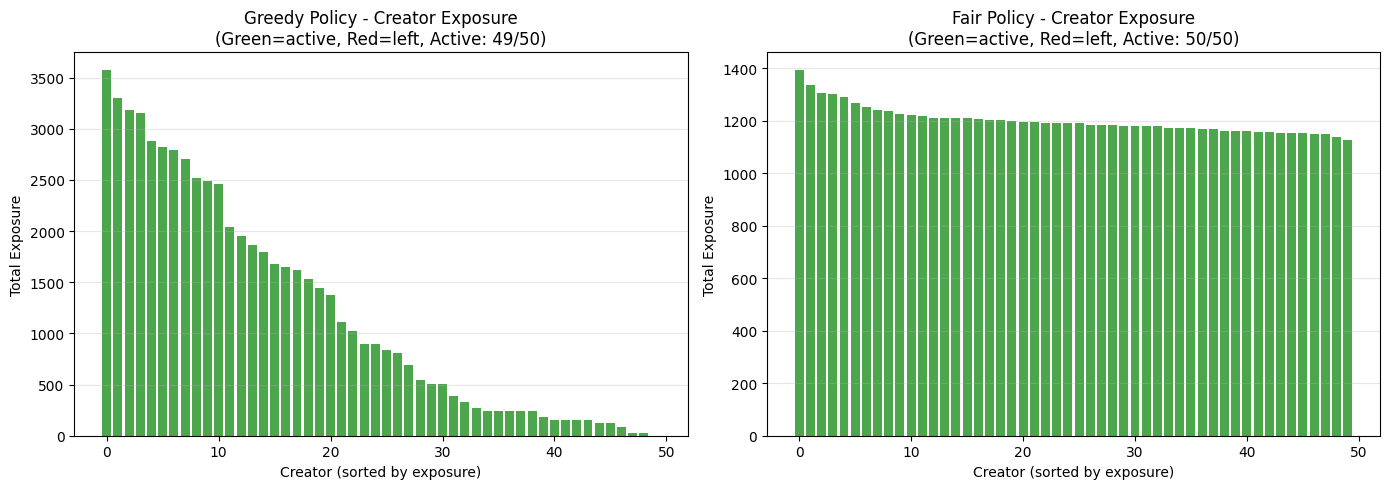

In [7]:
# Deep dive into creator exposure distribution
def analyze_creator_dynamics(policy_fn, n_rounds=30, **kwargs):
    eco = RecommendationEcosystem()
    exposure_snapshots = []
    
    for r in range(n_rounds):
        recs = policy_fn(eco, **kwargs)
        eco.recommend_and_observe(recs)
        if r % 10 == 0 or r == n_rounds - 1:
            exposure_snapshots.append({
                'round': r,
                'exposure': eco.creator_exposure.copy(),
                'active': eco.creator_active.copy(),
                'satisfaction': eco.creator_satisfaction.copy()
            })
    
    return exposure_snapshots

greedy_dynamics = analyze_creator_dynamics(greedy_engagement_policy)
fair_dynamics = analyze_creator_dynamics(fair_exposure_policy)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Creator exposure distribution at end
for ax, (dynamics, name) in zip(axes, [(greedy_dynamics, 'Greedy'), (fair_dynamics, 'Fair')]):
    final = dynamics[-1]
    sorted_exp = np.sort(final['exposure'])[::-1]
    colors_arr = ['green' if final['active'][np.where(final['exposure'] == e)[0][0]] else 'red'
                  for e in sorted_exp]
    ax.bar(range(len(sorted_exp)), sorted_exp, color=colors_arr, alpha=0.7)
    ax.set_xlabel('Creator (sorted by exposure)')
    ax.set_ylabel('Total Exposure')
    ax.set_title(f'{name} Policy - Creator Exposure\n'
                 f'(Green=active, Red=left, Active: {final["active"].sum()}/{len(final["active"])})')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 🏋️ Exercise 1: Implement an Adaptive Policy

Design a policy that automatically adjusts its weights based on ecosystem health metrics.
When creator satisfaction drops, increase the fairness weight.

In [8]:
# TODO: Implement adaptive policy
def adaptive_policy(eco, k=10, target_creator_sat=0.3, target_active_ratio=0.8):
    """Policy that adapts weights based on ecosystem health."""
    # TODO:
    # 1. Monitor creator satisfaction and active ratio
    # 2. If creator_satisfaction < target, increase fairness weight
    # 3. If active_creators/total < target_ratio, boost exposure for struggling creators
    # 4. Otherwise, focus on user satisfaction and revenue
    pass

print("Exercise 1: Implement adaptive policy")

Exercise 1: Implement adaptive policy


## 🏋️ Exercise 2: Simulate Marketplace Supply-Demand

Extend the ecosystem to model a two-sided marketplace where supply (available items)
and demand (user interests) must be balanced.

In [9]:
# TODO: Implement two-sided marketplace simulation
class MarketplaceEcosystem(RecommendationEcosystem):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # TODO: Add supply/demand dynamics
        # - Items have limited inventory
        # - Prices adjust based on demand
        # - Sellers decide whether to list items
    
    def update_supply_demand(self, recommendations):
        # TODO: Update prices and inventory
        pass

print("Exercise 2: Implement marketplace simulation")

Exercise 2: Implement marketplace simulation


## 🏋️ Exercise 3: Detect Ecosystem Collapse

Build an early warning system that detects when the ecosystem is heading toward collapse
(mass creator departure, user disengagement).

In [10]:
# TODO: Implement ecosystem health monitoring
def ecosystem_health_monitor(history, window=5):
    """Detect early signs of ecosystem collapse."""
    # TODO:
    # 1. Track rolling average of key metrics
    # 2. Alert if active_creators drops below threshold
    # 3. Alert if exposure_gini exceeds threshold
    # 4. Alert if user_satisfaction declining for N consecutive rounds
    # Return list of alerts
    pass

print("Exercise 3: Implement ecosystem health monitor")

Exercise 3: Implement ecosystem health monitor


## Summary

In this notebook, we explored multi-objective ecosystem optimization:

1. **Multi-stakeholder modeling**: Users, creators, advertisers, and platform
2. **Policy comparison**: Engagement, fairness, revenue, and balanced approaches
3. **Pareto frontier**: Finding optimal trade-off points between objectives
4. **Creator economy**: How recommendations affect creator participation and diversity
5. **Ecosystem health**: Monitoring and preventing platform collapse

### Key Takeaways

- Pure engagement optimization harms ecosystem diversity
- The Pareto frontier reveals the true trade-off space
- Creator retention is a leading indicator of ecosystem health
- Adaptive policies outperform fixed-weight approaches
- Long-term sustainability requires explicit multi-stakeholder optimization